# **Necessary Imports**

In [ ]:
!pip install keras_tuner
!pip install scikeras

In [ ]:
# Numerical arrays
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Neural network
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split

# Data Preprocessing
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# Model evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, auc, accuracy_score
import sklearn

from scikeras.wrappers import KerasClassifier
# Model optimization
from tensorflow.keras import regularizers
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# Hyperparameter tuning
from keras_tuner import RandomSearch
from sklearn.model_selection import GridSearchCV

import shap
sklearn.set_config(display='diagram')
from google.colab import drive
drive.mount('/content/drive')

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. **Data Loading and Preprocessing**

In [ ]:
# Reading the data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer-telco-churn/data/cleaned/cleaned_data.csv')

In [ ]:
print(("Dataset Shape:", df.shape))
print("Features:", df.columns.tolist())
print("Data types:", df.dtypes)

('Dataset Shape:', (7043, 21))
Features: ['Unnamed: 0', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Data types: Unnamed: 0            int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [ ]:
# remove gender and unnamed column since they are not needed
df = df.drop(["gender", "Unnamed: 0"], axis=1)

In [ ]:
# # Check for multicolinareality
# numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# # corr matrix
# corr_matrix = df[numerical_cols].corr()

# # remove multi col

In [ ]:
# # find highly correlatd pairs
# highly_correlated_pairs = []

# for i in range(len(corr_matrix.columns)):
#   for j in range(i):
#     if abs(corr_matrix.iloc[i, j]) > 0.8:
#       highly_correlated_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))


In [ ]:
# # Remove one from each correlated pair
# to_remove = []

# for f1, f2, corr_value in highly_correlated_pairs:
#   # Check correlation with target
#   corr_f1 = df[f1].corr(df['Churn'])
#   corr_f2 = df[f2].corr(df['Churn'])

#   if abs(corr_f1) > abs(corr_f2):   # absolute since the magnitude matters
#     to_remove.append(f2)
#   else:
#     to_remove.append(f1)

In [ ]:
# # Remove duplicates
# to_remove = list(set(to_remove))

In [ ]:
# if to_remove:
#   df = df.drop(to_remove, axis=1)
#   print("Removed features:", to_remove)

# **2. Data Splitting**

In [ ]:
# Seperate independent and dependent variables
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Get sizes
print("Training sets size:", X_train.shape, y_train.shape)
print("Testing sets sizes:", X_test.shape, y_test.shape)

Training sets size: (5634, 18) (5634,)
Testing sets sizes: (1409, 18) (1409,)


In [ ]:
# Get categorical (nominal + ordinal), numerical features for later preprocessing
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns.drop('Contract')  # Exclude the ordinal column
ordinal_feature = ['Contract']  # Contracts get better from Month-to-month to One year to Two year

# **3. Create Preprocessing Pipeline**

In [ ]:
# numerical
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())    # standard scaler for neural network
])

# Categorical (excluding ordinal)
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # encode nominal features
])

# Ordinal feature
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[
        ['Month-to-month', 'One year', 'Two year']
    ]))
])

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_feature),
        ('num', numerical_transformer, numerical_features)
    ]
)

In [ ]:
# Fit the preprocessor
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [ ]:
# Get the new preprocessed shapes
print("Preprocessed X train size:", X_train.shape)
print("Preprocessed X test size:", X_test.shape)

Preprocessed X train size: (5634, 41)
Preprocessed X test size: (1409, 41)


# **4. Handle Class Imbalance with SMOTE**

In [ ]:
# Fitting smote
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [ ]:
# Getting the new shapes
print("Training sets sizes after sampling:", X_train_balanced.shape, y_train_balanced.shape)

Training sets sizes after sampling: (8278, 41) (8278,)


In [ ]:
# Comoute mi scores
mi_scores = mutual_info_classif(X_train_balanced, y_train_balanced, random_state=42)

In [ ]:
# Get them as a dataframe
feature_names = preprocessor.get_feature_names_out()

mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

In [ ]:
mi_df.head(20)

,Feature,MI Score
38,num__tenure,0.280423
36,ord__Contract,0.168927
12,cat__OnlineSecurity_No,0.116028
39,num__MonthlyCharges,0.109584
34,cat__PaymentMethod_Electronic check,0.108699
21,cat__TechSupport_No,0.097833
15,cat__OnlineBackup_No,0.072449
10,cat__InternetService_Fiber optic,0.072046
30,cat__PaperlessBilling_No,0.061560
31,cat__PaperlessBilling_Yes,0.060306


In [ ]:
selector = SelectKBest(score_func=mutual_info_classif, k=20)
X_train_selected = selector.fit_transform(X_train_balanced, y_train_balanced)
X_test_selected = selector.transform(X_test)

In [ ]:
###### check for duplicates

In [ ]:
def build_nn(input_dim):
  """
  Builds a neural network for churn prediction
  """

  model = keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim, )),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    # Output layer
    tf.keras.layers.Dense(1, activation='sigmoid')  # churn or not
  ])
  return model
model = build_nn(X_train_selected.shape[1])

In [ ]:
# Get model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Compile the model
def compile_model(model, learning_rate=0.001):   # default value for learning rate
  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  metrics = [
      keras.metrics.BinaryAccuracy(name='accuracy'),   # predicted probs >= 0.5 then class 1
      keras.metrics.Precision(name='precision'),
      keras.metrics.Recall(name='recall'),
      keras.metrics.AUC(name='auc'),  # seperates positive and negative classes across all probability thresholds
      keras.metrics.AUC(name='prc', curve='PR') # Precision recall AUC (heavily focuses on positive class behaviour and performance under imbalance)
  ]

  model.compile(
      optimizer = optimizer,
      loss = 'binary_crossentropy',
      metrics = metrics
  )
  return model

model = compile_model(model, learning_rate=0.001)

In [ ]:
history = model.fit(
      X_train_selected,
      y_train_balanced,
      batch_size=32,
      epochs=50,
)

Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6690 - auc: 0.7295 - loss: 0.7107 - prc: 0.7062 - precision: 0.6556 - recall: 0.6994
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7401 - auc: 0.8197 - loss: 0.5648 - prc: 0.7976 - precision: 0.7203 - recall: 0.7769
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7510 - auc: 0.8261 - loss: 0.5517 - prc: 0.7993 - precision: 0.7345 - recall: 0.7917
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7612 - auc: 0.8394 - loss: 0.5251 - prc: 0.8199 - precision: 0.7458 - recall: 0.7917
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7669 - auc: 0.8458 - loss: 0.5157 - prc: 0.8223 - precision: 0.7525 - recall: 0.7937
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7627 - auc: 0.8381 - loss: 0.5203 - prc: 0.8161 - precision: 0.7440 - recall: 0.8005
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7760 - auc: 0.8508 - loss: 0

In [ ]:
train_metrics = model.evaluate(X_train_selected, y_train_balanced, verbose=0)

print(f"Training accuracy:", train_metrics[1])
print("All train metrics:", train_metrics)

Training accuracy: 0.8088910579681396
All train metrics: [0.42913708090782166, 0.8088910579681396, 0.7730087637901306, 0.8746073842048645, 0.8871027827262878, 0.8684567213058472]


In [ ]:
y_test_pred_probs = model.predict(X_test_selected)

y_test_pred = (y_test_pred_probs > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
print(roc_auc_score(y_test, y_test_pred_probs))

0.8203234389935158


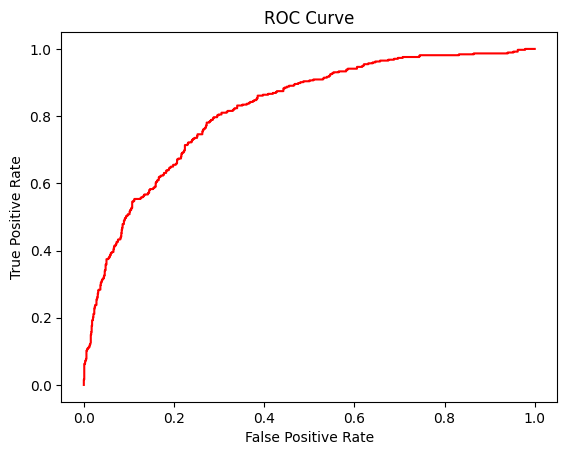

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_test_pred_probs)

plt.plot(fpr, tpr, c='r')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
# Perform early stopping
callbacks = [
      tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,  # stop is val loss does not improve in 15 epochs
        mode='min', # lower loss is better
        restore_best_weights=True,
        verbose=1
      )
  ]

In [ ]:
model.evaluate(X_test_selected, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7438 - auc: 0.8197 - loss: 0.5151 - prc: 0.6360 - precision: 0.5169 - recall: 0.7466


[0.5094432234764099,
 0.7480482459068298,
 0.5174953937530518,
 0.7513368725776672,
 0.8253403902053833,
 0.6394903659820557]

In [ ]:
tuned_predictions = model.predict(X_test_selected)
tuned_pred = (tuned_predictions > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


## **Class Weights**

In [ ]:
# Choose background for shap
background = X_train_selected[np.random.choice(X_train_selected.shape[0], 100, replace=False)]

In [ ]:
# Create the explainer
explainer = shap.DeepExplainer(model, background)

In [ ]:
# generate shap values
shap_values = explainer.shap_values(X_test_selected[:200])

In [ ]:
print(shap_values[0], shap_values[1]) # binary classification so 2 outputs

In [ ]:
# shap values for class churn == 1
sv = shap_values[1]

In [ ]:
print("SHAP values shape:", sv.shape)
print("X_test_sample shape:", X_test_sample.shape)
print("selected_feature_names length:", len(selected_feature_names))


In [ ]:
# Plot accuracy and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

In [ ]:
# Plot loss and validation loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the neural network
print(model.evaluate(X_test_selected, y_test))
print("AUC:", roc_auc_score(y_test, y_pred))
print(classificiation_report(y_test, y_pred))

In [ ]:
predictions = model.predict(X_test)
cm = confusion_matrix(y_test, predictions.round())
cm

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
param_grid = {
    'learning_rate': [0.0001, 0.0005, 0.001],
    'batch_size': [32,64,128],

}

# **Hyperparameter Tuning**

In [ ]:
input_dim = X_train_selected.shape[1]

def build_model(hp):
  global input_dim
  model = keras.Sequential()
  model.add(tf.keras.layers.Input(shape=(input_dim, ))) # input_dim for number of features

  # Tune number of layers
  for i in range(hp.Int('num_layers', 1, 3)): # try 1 to 3 hidden layers (different amounts may be underfitting/overfitting)
    model.add(tf.keras.layers.Dense(
        units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),

        # relu to prevent vanising gradients and suited for hidden layers
        activation='relu',

        # Prevent overfitting
        kernel_regularizer=regularizers.l2(hp.Float('l2', 1e-5, 1e-1, sampling='log'))
    ))
    model.add(tf.keras.layers.Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))

    # Normalize output of previous layers
    model.add(tf.keras.layers.BatchNormalization())

  model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

  model.compile(

                # Tune learning rate with log values
      optimizer=tf.keras.optimizers.Adam(
          learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
      ),
      loss='binary_crossentropy', # for binrary classification
      metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] # better for imbalanced data than accuracy
  )
  return model

In [ ]:
# Run hyperparameter search
tuner = RandomSearch(
    build_model,
    objective='val_auc',
    max_trials=10,
    executions_per_trial=2,
    directory='tuner_results'
)

Reloading Tuner from tuner_results/untitled_project/tuner0.json


In [ ]:
tuner.search(
    X_train_selected,
    y_train_balanced,
    epochs=30,
    validation_data=(X_test_selected, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)]
)

In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

In [ ]:
print("Best number of layers:", best_hps.get('num_layers'))

Best number of layers: 3


In [ ]:
for i in range(best_hps.get('num_layers')):
    print(f"Best units in layer {i}:", best_hps.get(f'units_{i}'))
    print("Best dropout rate:", best_hps.get('dropout'))
    print("Best L2:", best_hps.get('l2'))
    print("Best learning rate:", best_hps.get('learning_rate'))

Best units in layer 0: 128
Best dropout rate: 0.4
Best L2: 0.014459373877407505
Best learning rate: 0.0012259299618157364
Best units in layer 1: 224
Best dropout rate: 0.4
Best L2: 0.014459373877407505
Best learning rate: 0.0012259299618157364
Best units in layer 2: 256
Best dropout rate: 0.4
Best L2: 0.014459373877407505
Best learning rate: 0.0012259299618157364


In [ ]:
best_model = tuner.hypermodel.build(best_hps)

In [ ]:
history = best_model.fit(
    X_train_selected,
    y_train_balanced,
    epochs=100,  # more epochs now
    batch_size=32,
    validation_data=(X_test_selected, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Epoch 1/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7017 - auc: 0.7673 - loss: 4.8370 - val_accuracy: 0.6451 - val_auc: 0.8135 - val_loss: 1.8827
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7414 - auc: 0.8153 - loss: 1.4917 - val_accuracy: 0.7232 - val_auc: 0.8358 - val_loss: 0.9097
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7569 - auc: 0.8310 - loss: 0.8030 - val_accuracy: 0.7544 - val_auc: 0.8358 - val_loss: 0.6413
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7714 - auc: 0.8361 - loss: 0.6422 - val_accuracy: 0.7097 - val_auc: 0.8256 - val_loss: 0.6496
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7673 - auc: 0.8424 - loss: 0.5848 - val_accuracy: 0.7239 - val_auc: 0.8331 - val_loss: 0.5698
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7731 - auc: 0.8371 - loss: 0.5710 - val_accuracy: 0.7608 - val_auc: 0.8356 - val_loss: 0.5485
Epoch 7/100
259/259 ━━━━━━━━

In [ ]:
some_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim, )),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
some_model.compile(optimizer='Adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

In [ ]:
r = some_model.fit(X_train_selected, y_train_balanced, batch_size=32, epochs=50, validation_data=(X_test_selected, y_test))

Epoch 1/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6072 - loss: 0.7769 - val_accuracy: 0.7502 - val_loss: 0.5017
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7211 - loss: 0.5633 - val_accuracy: 0.7431 - val_loss: 0.5063
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7417 - loss: 0.5360 - val_accuracy: 0.7331 - val_loss: 0.5158
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7452 - loss: 0.5193 - val_accuracy: 0.7417 - val_loss: 0.5035
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7598 - loss: 0.5151 - val_accuracy: 0.7303 - val_loss: 0.5108
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7591 - loss: 0.5016 - val_accuracy: 0.7324 - val_loss: 0.5036
Epoch 7/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7631 - loss: 0.5019 - val_accuracy: 0.7395 - val_loss: 0.4989
Epoch 8/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7641 - loss: 0.4999 - val_accu

In [ ]:
some_model.evaluate(X_test_selected, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7389 - loss: 0.5052


[0.5020571351051331, 0.7423704862594604]

In [ ]:
predictions = some_model.predict(X_test_selected)
cm = confusion_matrix(y_test, (predictions > 0.5).astype(int))  # convert to binary from probabilities

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


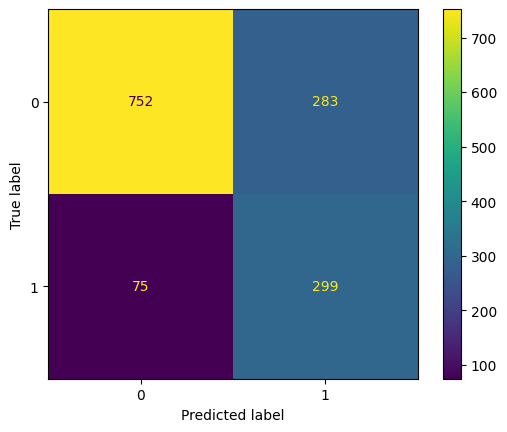

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
grid_params = {
    'num_units1': [64, 128],       # first hidden layer units
    'num_units2': [32, 64],        # second hidden layer units
    'dropout_rate': [0.3, 0.4],    # dropout rate
    'l2_reg': [0.001, 0.01],       # L2 regularization
    'learning_rate': [0.001, 0.005],  # learning rate for Adam
    'batch_size': [32, 64]         # batch size
}